In [8]:
import numpy as np
from scipy.special import gamma, gammaincc
from scipy.optimize import root_scalar

In [9]:
R_input_1 = 2/3600 # Rainfall rate [kg/m2/s] (if in [mm/h] divide by 3600)
R_input_2 = 20/3600 # Rainfall rate [kg/m2/s]
v = 100 # [cm/s]
Dc = 0.08 # Critical drop diameter for evaporation[cm]

#### Functions

In [10]:
# --- Parameters of empirical mu(Lambda) relation ---
def mu_from_lambda(Lambda):
    """Lambda (float): Gamma slope parameter [1/cm]"""
    return -0.016*(Lambda/10)**2 + 1.213*(Lambda/10) -1.957

# --- Gamma function helper ---
def incomplete_gamma(n, x):
    return gamma(n) * gammaincc(n, x)

# --- N0 from μ ---
def N0_from_mu(mu):
    """N0 [m-3 cm-1-mu]"""
    return 6e4 * np.exp(3.2 * mu)

# --- Terminal drop size limit ---
def D_prime(vb, a):
    return vb / a

# --- Full equation: R_model - R_target ---
def rainfall_equation_lambda_only(Lambda, R_target, vb ,a=3500):
    mu = mu_from_lambda(Lambda)
    Dp = D_prime(vb, a)
    N0 = N0_from_mu(mu)

    G1 = incomplete_gamma(5 + mu, Lambda * Dp)
    G2 = incomplete_gamma(4 + mu, Lambda * Dp)

    R_model = (np.pi / 6) * N0 * (
        a * G1 / Lambda**(5 + mu) - (vb) * G2 / Lambda**(4 + mu)
    )*1e-5
    return R_model - R_target

# --- Solver for Lambda ---
def solve_lambda_mu_dependent(R_target,vb, a=3500, bracket=(1, 300)):
    result = root_scalar(
        rainfall_equation_lambda_only,
        args=(R_target,vb, a),
        bracket=bracket,
        method='brentq'
    )
    if result.converged:
        return result.root
    else:
        raise RuntimeError("Lambda root-finding did not converge")



def precipitation_rate(R, mu, Lambda, Dc, Vb, a=3500, rho_w=1000):
    """
    Compute precipitation rate at the ground using gamma DSD.

    Parameters:
        R (float): Rainfall rate [mm/hr]
        mu (float): Gamma shape parameter
        Lambda (float): Gamma slope parameter [1/cm]
        Dc (float): Critical drop diameter [cm]
        a (float): Terminal velocity coefficient [1/s]
        Vb (float): Updraft velocity [cm/s]
        rho_w (float): Water density [kg/m^3]

    Returns:
        P (float): Precipitation rate at the ground [kg/m^2/s]
    """
    N0 = N0_from_mu(mu)
    pi_over_6 = np.pi / 6
    D3 = Dc**3
    LambdaDc = Lambda * Dc
    LambdaVb = Lambda * Vb / a

    if Vb / a > Dc:
        
        term1 = a * incomplete_gamma(mu + 2, LambdaVb) / Lambda**(mu + 2)
        
        term2 = Vb * incomplete_gamma(max(-0.9999,mu) + 1, LambdaVb) / Lambda**(max(-0.9999,mu) + 1)
        print(term2)
        P = R - (pi_over_6 * rho_w * N0 * D3 * (term1 - term2))*10**(-8)
    else:
        t1 = a  * incomplete_gamma(mu + 5, LambdaDc) / Lambda**(mu + 5)
        t2 = Vb * incomplete_gamma(mu + 4, LambdaDc) / Lambda**(mu + 4)
        t3 = a  * incomplete_gamma(mu + 2, LambdaDc) / Lambda**(mu + 2)
        t4 = Vb * incomplete_gamma(max(-0.9999,mu) + 1, LambdaDc) / Lambda**(max(-0.9999,mu) + 1)
        P = (pi_over_6 * rho_w *  N0 * (t1 - t2 - D3*t3 + D3*t4))*10**(-8)

    return P  # in [kg/m^2/s], which is mm/s because ρw = 1000

In [11]:
# --- Example usage ---
Lambda_result = solve_lambda_mu_dependent(R_input_1,v/2)#*(10**8/1000))
Lambda_result2 = solve_lambda_mu_dependent(R_input_2,v/2)#*(10**8/1000))
mu_result = mu_from_lambda(Lambda_result)
mu_result2 = mu_from_lambda(Lambda_result2)

print(f"Lambda = {Lambda_result:.4f} [1/cm]")
print(f"mu(Lambda) = {mu_result:.4f}")

P = max(0,precipitation_rate(R_input_1, mu_result, Lambda_result, Dc,v/2))
P2 = max(0,precipitation_rate(R_input_2, mu_result2, Lambda_result2, Dc,v/2))

Lambda = 122.0115 [1/cm]
mu(Lambda) = 10.4611


(0.0, 3.0)

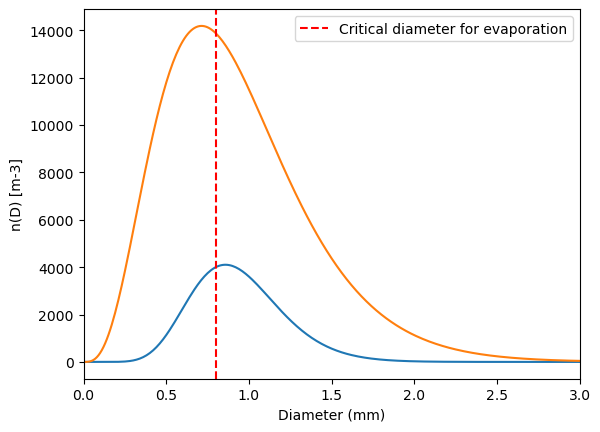

In [12]:
import matplotlib.pyplot as plt

D = np.linspace(0.001,1,1000)
N = 6e4 * np.exp(3.2 * mu_result)* D**(mu_result)*np.exp(-Lambda_result*D)#plt.ylim(0,100)
N_2 = 6e4 * np.exp(3.2 * mu_result2)* D**(mu_result2)*np.exp(-Lambda_result2*D)
plt.plot(D*10,N)
plt.plot(D*10,N_2)
plt.axvline(x=Dc*10,color='r',linestyle='--',label='Critical diameter for evaporation')
plt.xlabel('Diameter (mm)')
plt.ylabel('n(D) [m-3]')
plt.legend()
plt.xlim(0,3)